# Mind the Gap: Figures for the Final Report

This notebook generates all figures for the CS 563 final report.

Run `pipeline/05_analyze.py` first to produce `data/results/classified_bugs.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import json
import numpy as np
from pathlib import Path

RESULTS_DIR = Path('../data/results')
FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

df = pd.read_csv(RESULTS_DIR / 'classified_bugs.csv')
print(f'Total tests: {len(df)}, Bugs: {df.bug_id.nunique()}, Projects: {df.project.nunique()}')

# --- Global style for IEEE 2-column publication ---
plt.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'serif',
})

# Short single-line labels to avoid overlap
LABEL_MAP = {
    'RETURN_VALUE': 'Return Val.',
    'BOUNDARY_CONDITION': 'Boundary',
    'NONE_NULL_HANDLING': 'None/Null',
    'EXCEPTION_HANDLING': 'Exception',
    'STATE_TRANSITION': 'State Trans.',
    'TYPE_COERCION': 'Type Coerce',
    'OTHER': 'Other',
}

# Full names for contexts with more space (legends, y-axis)
LABEL_FULL = {
    'RETURN_VALUE': 'Return Value',
    'BOUNDARY_CONDITION': 'Boundary Condition',
    'NONE_NULL_HANDLING': 'None/Null Handling',
    'EXCEPTION_HANDLING': 'Exception Handling',
    'STATE_TRANSITION': 'State Transition',
    'TYPE_COERCION': 'Type Coercion',
    'OTHER': 'Other',
}

PALETTE = {
    'Return Val.': '#4477AA',
    'Boundary': '#EE6677',
    'None/Null': '#228833',
    'Exception': '#CCBB44',
    'Other': '#AA3377',
    'State Trans.': '#66CCEE',
    'Type Coerce': '#BBBBBB',
}

PALETTE_FULL = {v: PALETTE[LABEL_MAP[k]] for k, v in LABEL_FULL.items()}

df['gap_label'] = df['gap_type'].map(LABEL_MAP)
df['gap_label_full'] = df['gap_type'].map(LABEL_FULL)

# Canonical order: by frequency (descending). Used consistently across all figures.
_freq = df['gap_type'].value_counts()
GAP_ORDER = _freq.index.tolist()                              # raw keys
GAP_ORDER_SHORT = [LABEL_MAP[g] for g in GAP_ORDER]           # short labels
GAP_ORDER_FULL = [LABEL_FULL[g] for g in GAP_ORDER]           # full labels

print('Gap type order (by frequency):', GAP_ORDER_SHORT)
df.head()

def format_median(value):
    if float(value).is_integer():
        return f'{int(value)}'
    return f'{value:.1f}'


Total tests: 211, Bugs: 139, Projects: 14
Gap type order (by frequency): ['Return Val.', 'Boundary', 'None/Null', 'Exception', 'Other']


,bug_id,project,test_file,test_function,gap_type,gap_type_priority_matched,loc,assertion_count,exception_testing,fixture_count,parameterized,cyclomatic_complexity,fix_loc_added,fix_loc_deleted,fix_files_changed,gap_type_llm,gap_label,gap_label_full
0,PySnooper_1,PySnooper,tests/test_chinese.py,test_chinese,NONE_NULL_HANDLING,4,24,0,0,0,0,2,6,2,2,NaN,None/Null,None/Null Handling
1,PySnooper_2,PySnooper,tests/test_pysnooper.py,test_custom_repr_single,OTHER,7,20,0,0,0,0,1,3,0,1,NaN,Other,Other
2,PySnooper_3,PySnooper,tests/test_pysnooper.py,test_file_output,RETURN_VALUE,5,24,1,0,0,0,2,1,1,1,NaN,Return Val.,Return Value
3,ansible_1,ansible,test/units/galaxy/test_collection.py,test_verify_collections_no_version,EXCEPTION_HANDLING,1,12,1,1,3,0,2,5,0,1,NaN,Exception,Exception Handling
4,ansible_10,ansible,test/units/modules/system/test_pamd.py,test_remove_last_rule,RETURN_VALUE,5,4,2,0,0,0,1,6,1,2,NaN,Return Val.,Return Value


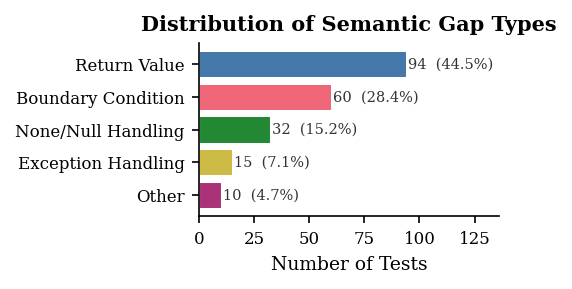

In [2]:
# Figure 1: Gap Type Distribution (horizontal bar chart)
counts = df['gap_type'].value_counts()
# Use canonical frequency order
order = GAP_ORDER
order_labels = [LABEL_FULL[g] for g in order]
total = len(df)

fig, ax = plt.subplots(figsize=(3.5, 2.0))
colors = [PALETTE[LABEL_MAP[g]] for g in order]
bars = ax.barh(range(len(order)), [counts[g] for g in order],
               color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order_labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Number of Tests')
ax.set_title('Distribution of Semantic Gap Types', fontweight='bold')

for i, (bar, g) in enumerate(zip(bars, order)):
    count = counts[g]
    pct = 100 * count / total
    ax.text(bar.get_width() + 1.0, bar.get_y() + bar.get_height() / 2,
            f'{count}  ({pct:.1f}%)', va='center', fontsize=7, color='#333333')

ax.set_xlim(0, counts.values[0] * 1.45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_gap_type_distribution.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'fig1_gap_type_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1623615/3223869239.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(data=df, x='gap_label', y='loc', order=present_order, ax=ax,
/tmp/ipykernel_1623615/3223869239.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(present_order, rotation=25, ha='right', fontsize=7.5)


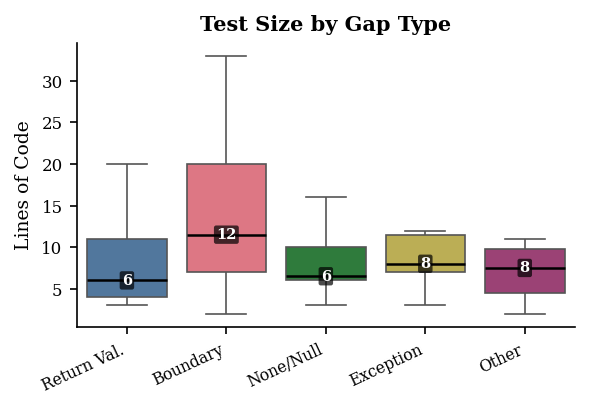

In [3]:
# Figure 2: LOC by Gap Type (box plot) -- ordered by gap type frequency
order = GAP_ORDER_SHORT
present_order = [l for l in order if l in df['gap_label'].values]
present_palette = {k: PALETTE[k] for k in present_order}

fig, ax = plt.subplots(figsize=(4.0, 2.8))
bp = sns.boxplot(data=df, x='gap_label', y='loc', order=present_order, ax=ax,
                 palette=present_palette, showfliers=False, linewidth=0.8,
                 medianprops=dict(color='black', linewidth=1.2),
                 boxprops=dict(edgecolor='#555555'),
                 whiskerprops=dict(color='#555555'),
                 capprops=dict(color='#555555'))
ax.set_xlabel('')
ax.set_ylabel('Lines of Code')
ax.set_title('Test Size by Gap Type', fontweight='bold')
ax.set_xticklabels(present_order, rotation=25, ha='right', fontsize=7.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotate median values: white text centered on the median line
medians = df.groupby('gap_label')['loc'].median()
for i, label in enumerate(present_order):
    med = medians[label]
    ax.annotate(format_median(med), xy=(i, med), ha='center', va='center',
                fontsize=7, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.15', fc='black', alpha=0.7, lw=0))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_loc_by_gap_type.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'fig2_loc_by_gap_type.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1623615/2543585049.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(data=df, x='gap_label', y='assertion_count', order=present_order, ax=ax,
/tmp/ipykernel_1623615/2543585049.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(present_order, rotation=25, ha='right', fontsize=7.5)


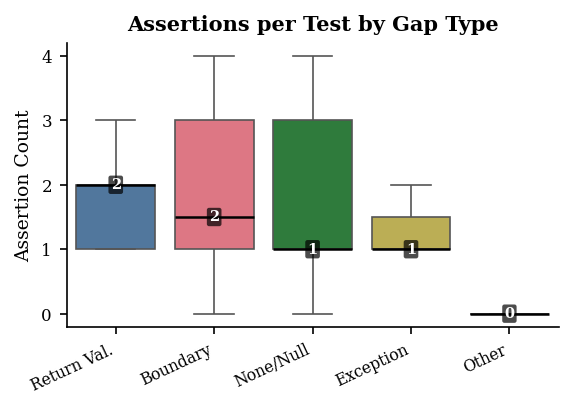

In [4]:
# Figure 3: Assertion count by Gap Type (box plot) -- same frequency order as Fig 2
order = GAP_ORDER_SHORT
present_order = [l for l in order if l in df['gap_label'].values]
present_palette = {k: PALETTE[k] for k in present_order}

fig, ax = plt.subplots(figsize=(4.0, 2.8))
bp = sns.boxplot(data=df, x='gap_label', y='assertion_count', order=present_order, ax=ax,
                 palette=present_palette, showfliers=False, linewidth=0.8,
                 medianprops=dict(color='black', linewidth=1.2),
                 boxprops=dict(edgecolor='#555555'),
                 whiskerprops=dict(color='#555555'),
                 capprops=dict(color='#555555'))
ax.set_xlabel('')
ax.set_ylabel('Assertion Count')
ax.set_title('Assertions per Test by Gap Type', fontweight='bold')
ax.set_xticklabels(present_order, rotation=25, ha='right', fontsize=7.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotate median values: white text on black badge at median line
medians = df.groupby('gap_label')['assertion_count'].median()
for i, label in enumerate(present_order):
    med = medians[label]
    ax.annotate(format_median(med), xy=(i, med), ha='center', va='center',
                fontsize=7, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.15', fc='black', alpha=0.7, lw=0))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3_assertions_by_gap_type.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'fig3_assertions_by_gap_type.png', dpi=300, bbox_inches='tight')
plt.show()

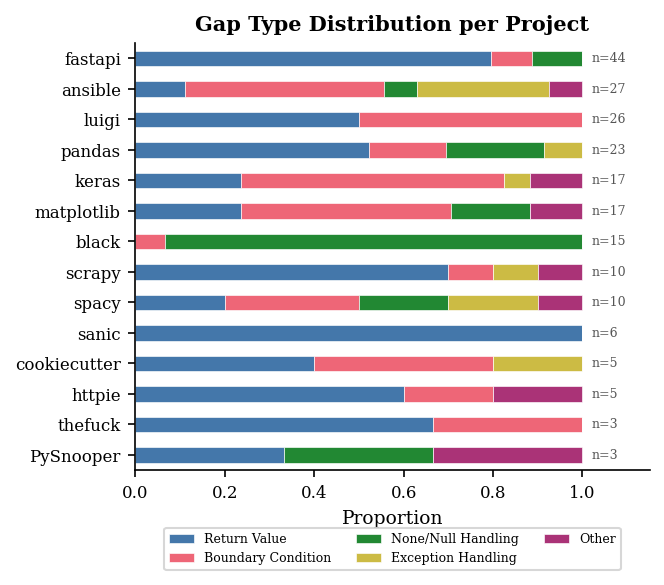

In [5]:
# Figure 4: Gap type distribution per project (horizontal stacked bar)
pivot = df.groupby(['project', 'gap_type']).size().unstack(fill_value=0)
totals = pivot.sum(axis=1)
pivot = pivot.loc[totals.sort_values(ascending=True).index]
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

# Reorder columns to match canonical frequency order
col_order = [g for g in GAP_ORDER if g in pivot_norm.columns]
pivot_norm = pivot_norm[col_order]
pivot = pivot[col_order]

# Rename columns to full labels
pivot_norm.columns = [LABEL_FULL[c] for c in pivot_norm.columns]

fig, ax = plt.subplots(figsize=(4.5, 4.0))
pivot_norm.plot(kind='barh', stacked=True, ax=ax,
                color=[PALETTE_FULL[c] for c in pivot_norm.columns],
                edgecolor='white', linewidth=0.3)
ax.set_xlabel('Proportion')
ax.set_ylabel('')
ax.set_title('Gap Type Distribution per Project', fontweight='bold')

# Move legend below the chart to avoid overlap with annotations
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fontsize=6, frameon=True, framealpha=0.9,
          edgecolor='lightgray', ncol=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, 1.15)

# Add test count annotations past the bar end
for i, (project, row) in enumerate(pivot.iterrows()):
    total = int(row.sum())
    ax.text(1.02, i, f'n={total}', va='center', ha='left', fontsize=6, color='#555555')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4_gap_type_by_project.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'fig4_gap_type_by_project.png', dpi=300, bbox_inches='tight')
plt.show()

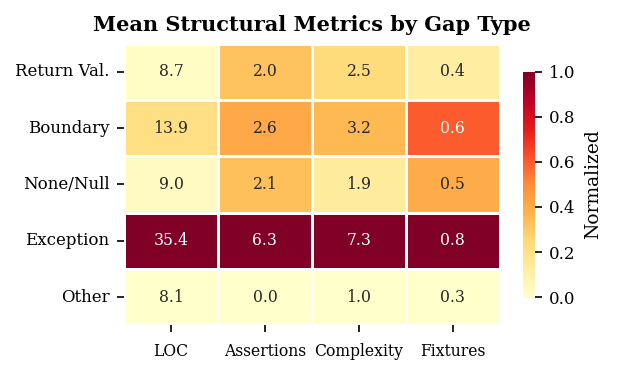

In [6]:
# Figure 5: Heatmap of structural metrics by gap type
metrics = ['loc', 'assertion_count', 'cyclomatic_complexity', 'fixture_count']
metric_labels = ['LOC', 'Assertions', 'Complexity', 'Fixtures']

# Use canonical frequency order for rows
row_order = [l for l in GAP_ORDER_SHORT if l in df['gap_label'].values]
grouped = df.groupby('gap_label')[metrics].mean().loc[row_order]
normalized = (grouped - grouped.min()) / (grouped.max() - grouped.min() + 1e-9)

fig, ax = plt.subplots(figsize=(4.2, 2.6))
sns.heatmap(normalized, annot=grouped.round(1).values, fmt='', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Normalized'},
            xticklabels=metric_labels, yticklabels=row_order,
            annot_kws={'fontsize': 7.5})
ax.set_title('Mean Structural Metrics by Gap Type', fontweight='bold')
ax.set_ylabel('')
ax.set_xticklabels(metric_labels, rotation=0, ha='center', fontsize=7.5)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# Give x-axis labels more breathing room
ax.tick_params(axis='x', pad=5)

plt.tight_layout(pad=1.2)
plt.savefig(FIGURES_DIR / 'fig5_metrics_heatmap.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'fig5_metrics_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1623615/572370071.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(data=bug_fix_df, x='gap_label', y='fix_loc_added', order=present_order, ax=ax,
/tmp/ipykernel_1623615/572370071.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(present_order, rotation=25, ha='right', fontsize=7.5)


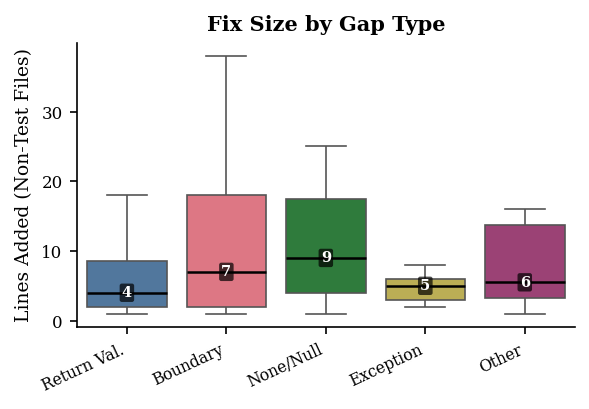

Fig 6 saved.


In [7]:
# Figure 6: Fix Size (LOC Added) by Gap Type (box plot, bug level)
# Fix metrics are per bug, not per test. Deduplicate to one row per bug using
# the same modal gap-type assignment as pipeline/05_analyze.py.
bug_fix_df = (
    df.groupby('bug_id')
      .apply(lambda g: pd.Series({
          'gap_type': g['gap_type'].mode().iloc[0],
          'fix_loc_added': g['fix_loc_added'].iloc[0],
      }))
      .reset_index()
)
bug_fix_df['gap_label'] = bug_fix_df['gap_type'].map(LABEL_MAP)

order = GAP_ORDER_SHORT
present_order = [l for l in order if l in bug_fix_df['gap_label'].values]
present_palette = {k: PALETTE[k] for k in present_order}

fig, ax = plt.subplots(figsize=(4.0, 2.8))
bp = sns.boxplot(data=bug_fix_df, x='gap_label', y='fix_loc_added', order=present_order, ax=ax,
                 palette=present_palette, showfliers=False, linewidth=0.8,
                 medianprops=dict(color='black', linewidth=1.2),
                 boxprops=dict(edgecolor='#555555'),
                 whiskerprops=dict(color='#555555'),
                 capprops=dict(color='#555555'))
ax.set_xlabel('')
ax.set_ylabel('Lines Added (Non-Test Files)')
ax.set_title('Fix Size by Gap Type', fontweight='bold')
ax.set_xticklabels(present_order, rotation=25, ha='right', fontsize=7.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotate median values
medians = bug_fix_df.groupby('gap_label')['fix_loc_added'].median()
for i, label in enumerate(present_order):
    med = medians[label]
    ax.annotate(format_median(med), xy=(i, med), ha='center', va='center',
                fontsize=7, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.15', fc='black', alpha=0.7, lw=0))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig6_fix_loc_by_gap_type.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'fig6_fix_loc_by_gap_type.png', dpi=300, bbox_inches='tight')
plt.show()
print('Fig 6 saved.')

In [8]:
# Summary stats table (for paper)
summary = df.groupby('gap_type')[['loc', 'assertion_count', 'cyclomatic_complexity']].agg(['mean', 'median', 'std'])
summary.columns = ['_'.join(c) for c in summary.columns]
summary['count'] = df.groupby('gap_type').size()
summary['pct'] = (summary['count'] / len(df) * 100).round(1)
print(summary.sort_values('count', ascending=False).to_string())

                     loc_mean  loc_median    loc_std  assertion_count_mean  assertion_count_median  assertion_count_std  cyclomatic_complexity_mean  cyclomatic_complexity_median  cyclomatic_complexity_std  count   pct
gap_type                                                                                                                                                                                                                 
RETURN_VALUE         8.744681         6.0   8.298123              2.010638                     2.0             1.355948                    2.468085                           2.0                   1.597728     94  44.5
BOUNDARY_CONDITION  13.916667        11.5   9.137911              2.550000                     1.5             3.341699                    3.233333                           2.0                   3.533696     60  28.4
NONE_NULL_HANDLING   9.031250         6.5   5.822561              2.062500                     1.0             1.949979         